In [7]:
import IPython.display as ipd

import os, sys
current_path = os.getcwd()
path_parts = current_path.split(os.sep)
idx = path_parts.index("occupancy-estimation")
homepath = os.sep.join(path_parts[:idx + 1]) +"/"
sys.path.insert(0,homepath)

%load_ext autoreload 
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
import numpy as np
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

from dataset_configs import get_all_configs
from dataset_configs import get_some_configs
from vacuum_plots_many import loader, loader_double





The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
from masking import make_inclusion_mask
from processing import get_maps, prepare_maps
from configuration import get_file_config
from estimation import plot_extrapolation_estimate
from logger import setup_logger
from estimation import _calculate_statistics, _analyze_threshold_trends,plot_extrapolation_estimate_new
import logging 
logger = setup_logger()
logger.setLevel(logging.WARNING)
# logger.setLevel(logging.INFO)


In [10]:
from estimation import _calculate_statistics, _analyze_threshold_trends,plot_extrapolation_estimate_new
from dataset_configs import apply_config_rsEGFP2
from dataset_configs import apply_config_PL_3ps
%matplotlib widget
if False:
    config = apply_config_PL_3ps()

    unscaled_dark, unscaled_triggered = get_maps(config)
    config["map_processing"]["diffmap_v2_correction"]=False
    config["map_processing"]["diffmap_mean_correction"]=False
    diffmap, map_dark, _ = prepare_maps(unscaled_dark, unscaled_triggered, config)

    diffmap_np = diffmap.to_3d_numpy_map(map_sampling=config["general"]["map_sampling"])
    logger.warning(
        f"Diffmap Mean: {diffmap_np.mean():.6f}, Std: {diffmap_np.std():.6f}"
    )
    inclusion_mask = make_inclusion_mask(diffmap, map_dark, config)

    config["plot"]["set_ylim"] = ((0, 0.22))
    # plot_extrapolation_estimate(diffmap, map_dark, inclusion_mask, config)
    plot_extrapolation_estimate_new(diffmap, map_dark, inclusion_mask, config)

In [11]:
map_dark_base = None

0 11_100us/100us 11_100us
1 9_10us/10us 9_10us
3 7_30ns/30ns 7_30ns
5 3_300ps/300ps 3_300ps
6 10_30us/30us 10_30us
7 2_3ps/3ps 2_3ps
8 4_1ns/1ns 4_1ns
10 8_1us/1us 8_1us
13 6_10ns/10ns 6_10ns
14 5_3ns/3ns 5_3ns
1.2172365
--- Calibrating Absolute Densities for /Users/sbielfel/Nextcloud2/time_resolved/data/photolyase/1_superdark/superdark_deposit.pdb ---
Generating protein and solvent masks...
Estimated rho_atom offset (mean shift inside protein): 0.32244
Running 1D bounded optimization for rho_bulk...


2026-03-14 13:05:44,602: logger: WARNING: Estimated rho_atom shift (0.3224) and combined rho (rho_atom + share_solvent * rho_bulk) (0.3048 0.1662+0.5358*0.2585) differ by more than 0.01 e-/Å³. This may indicate an issue with the estimation or the maps. (processing.py:541)
2026-03-14 13:05:44,762: logger: WARNING: Used threshold for posmask: 0.413, found 3120 blobs (masking.py:133)


Optimal rho_bulk: 0.2585 e-/Å³


2026-03-14 13:05:45,431: logger: WARNING: Excluding an addtional 65 voxels from mask duedark map smaller than mean + 0 * sigma (deactivate via 'exclude_negative_dark' parameter) (masking.py:299)
2026-03-14 13:05:45,432: logger: WARNING: Excluding voxels with positive difference density from mask (activate via 'exclude_positive_diffmap' parameter) (masking.py:302)
2026-03-14 13:05:45,518: logger: WARNING: Mean of diffmap_np: 9.821045886260205e-13, Mean of map_dark_np: 0.30477839708328247 (estimation.py:642)
2026-03-14 13:05:45,659: logger: WARNING: Used threshold for posmask: 0.438, found 2650 blobs (masking.py:133)
2026-03-14 13:05:46,264: logger: WARNING: Excluding an addtional 54 voxels from mask duedark map smaller than mean + 0 * sigma (deactivate via 'exclude_negative_dark' parameter) (masking.py:299)
2026-03-14 13:05:46,264: logger: WARNING: Excluding voxels with positive difference density from mask (activate via 'exclude_positive_diffmap' parameter) (masking.py:302)
2026-03-14 

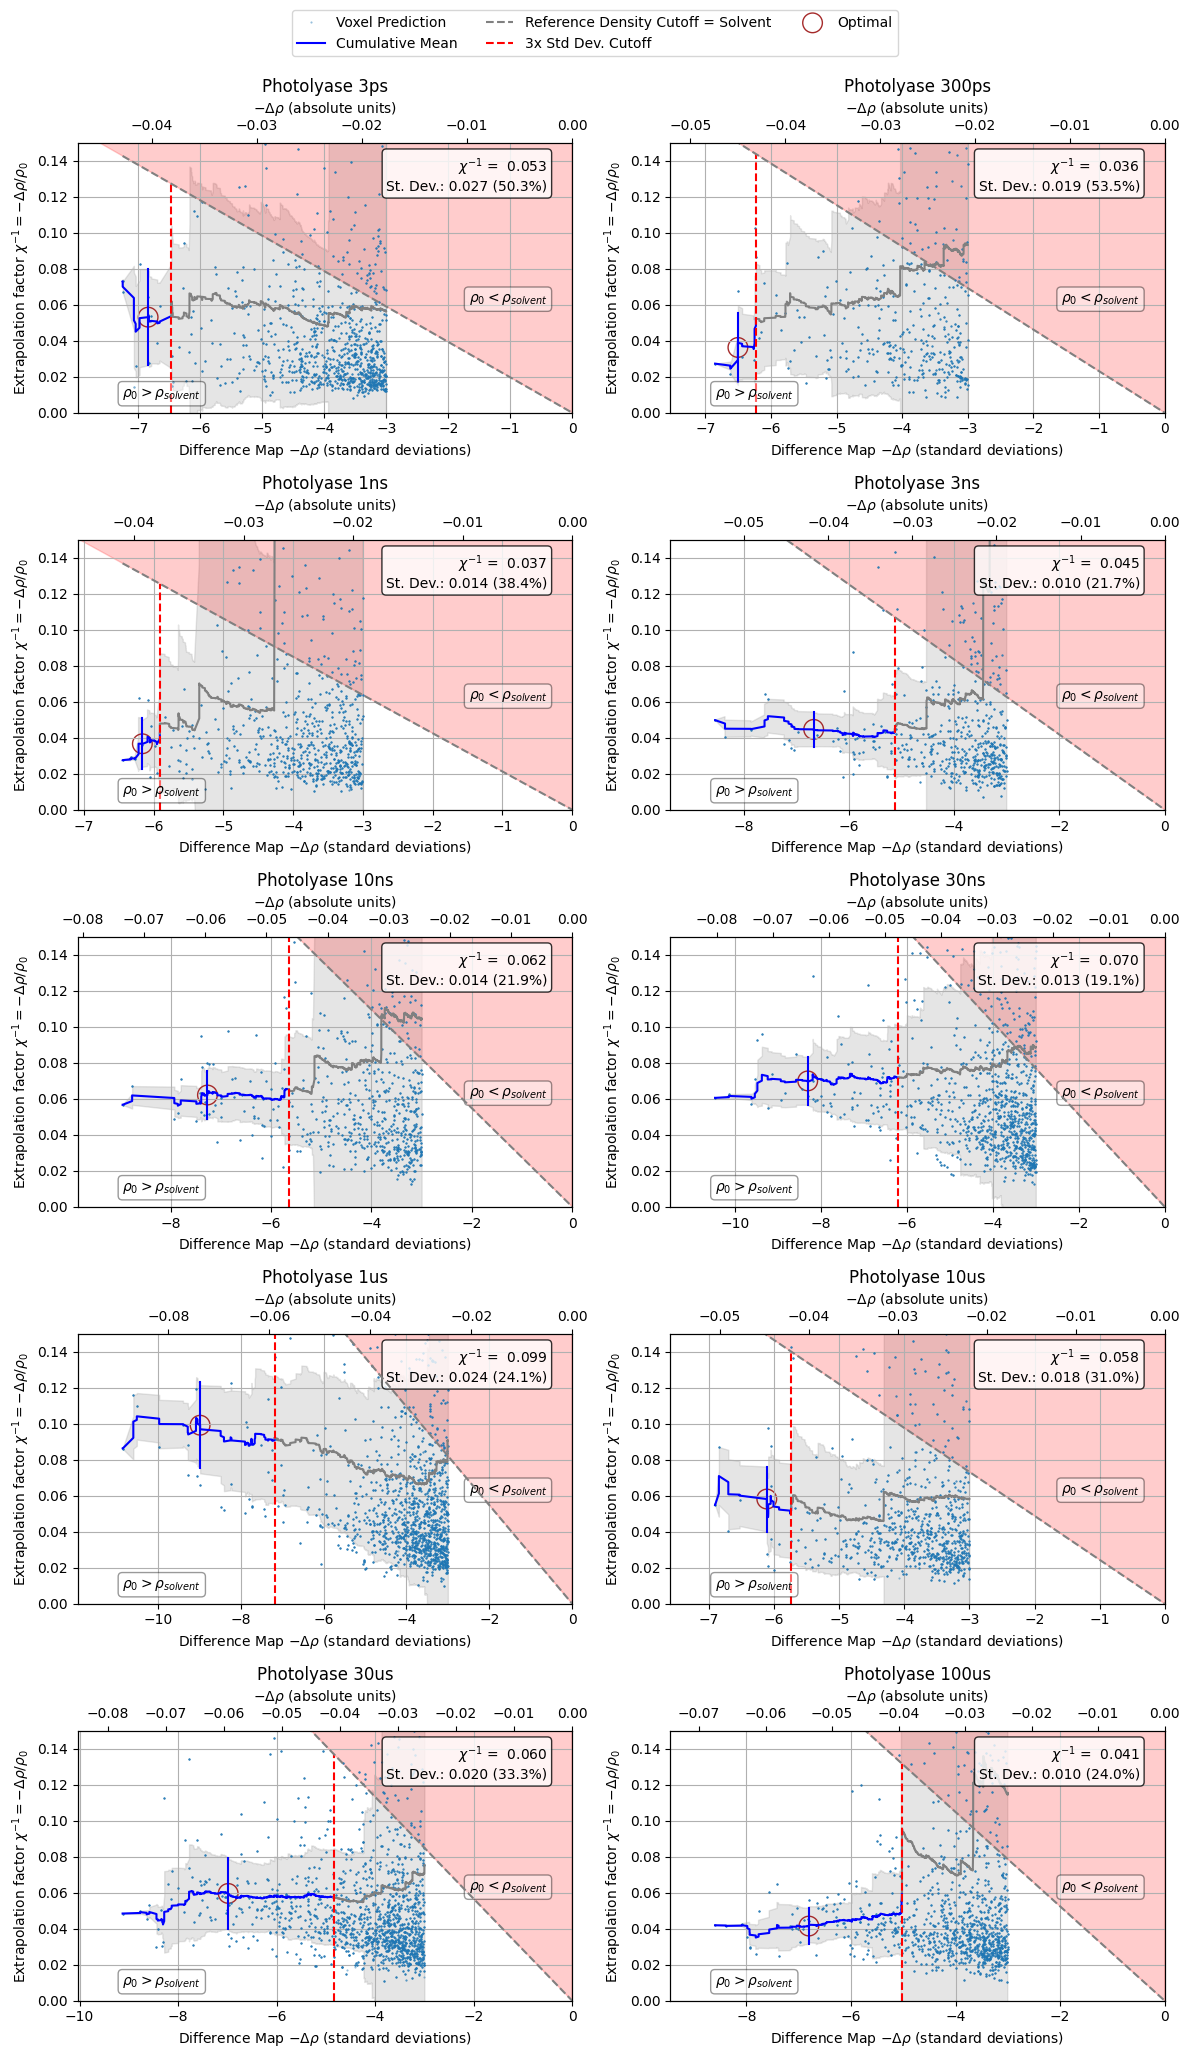

In [12]:
import numpy as np
from dataset_configs import get_all_PL_configs
from masking import make_inclusion_mask
from estimation import plot_extrapolation_estimate_new
from processing import get_maps_diff, get_map_dark
import matplotlib.pyplot as plt

plt.close("all")
%matplotlib inline
# 1. Create the main figure
fig,axs = plt.subplots(5,2, figsize=(12, 20), tight_layout=True)

configs = get_all_PL_configs(get_diff=True)

if map_dark_base is None:
    config = configs[0]
    config["general"]["high_resolution_limit"] = 2.0
    map_dark_base, diffmap = get_maps_diff(config)


# 2. Define the 2x2 outer grid
for i, (ax, config) in enumerate(zip(axs.flatten(), configs)):

    ax.set_title(config["general"]["name_human"])
    config["masking"]["dark_size_threshold"] = 0
    map_dark, diffmap = get_maps_diff(config, map_dark=map_dark_base)


    inclusion_mask_nse = make_inclusion_mask(diffmap, map_dark, config)



    plot_extrapolation_estimate_new(diffmap, map_dark, inclusion_mask_nse, config, ax)
    ax.set_ylim(0,0.15)

handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, 
    loc='upper center', 
    ncol=3,             # Adjust ncol to spread them horizontally
    bbox_to_anchor=(0.5, 1.03)) # Moves it above the subplots

# 3. Use tight_layout but leave room at the top for the legend
plt.tight_layout()


In [6]:
from xtr_maps import save_to_folder
from configuration import load_homepath

home_path = load_homepath()
parameters = {
    "folder": os.path.join(home_path, "illustration_maps") + "/",
    "xtr_prefix": "xtr"
}
if False:
    save_dict = {"a" : 15}
    save_to_folder(diffmap, map_dark, parameters, config['input_files'], save_dict)

2026-03-14 13:08:14,714: logger: WARNING: Different resolution limits in dark and triggered maps: 2.60 A vs 2.60 A (processing.py:94)


0 11_100us/100us 11_100us
1 9_10us/10us 9_10us
3 7_30ns/30ns 7_30ns
5 3_300ps/300ps 3_300ps
6 10_30us/30us 10_30us
7 2_3ps/3ps 2_3ps
8 4_1ns/1ns 4_1ns
10 8_1us/1us 8_1us
13 6_10ns/10ns 6_10ns
14 5_3ns/3ns 5_3ns
changed plot


/Users/sbielfel/anaconda3/envs/fml/lib/python3.13/site-packages/scipy/optimize/_lsq/least_squares.py:221: RuntimeWarning: overflow encountered in square
  z = (f / f_scale) ** 2
2026-03-14 13:08:17,731: logger: WARNING: Loaded meta from file: (processing.py:139)


2026-03-14 13:08:18 [info     ] scaling: native --> calculated weight_using_uncertainties=True
2026-03-14 13:08:18 [info     ] scaling: derivative --> calculated weight_using_uncertainties=True
2026-03-14 13:08:18 [info     ] Computing difference map.     
2026-03-14 13:08:18 [info     ]   using fixed                  kparameter=0.16
2026-03-14 13:08:18 [info     ] TV denoising with fixed weight weight=0.005043783982298454
2026-03-14 13:08:21 [info     ] Map TV-denoised with fixed weight final_negentropy=1.89e-01 initial_negentropy=1.52e-03 weight=0.005043783982298454


2026-03-14 13:08:21,849: logger: WARNING: Diffmap Mean: 0.000000, Std: 0.002933 (vacuum_plots_many.py:36)
2026-03-14 13:08:21,892: logger: WARNING: Used threshold for posmask: 0.068, found 579 blobs (masking.py:133)
2026-03-14 13:08:22,172: logger: WARNING: Excluding an addtional 605 voxels from mask duedark map smaller than mean + 0.0 * sigma (deactivate via 'exclude_negative_dark' parameter) (masking.py:299)
2026-03-14 13:08:22,172: logger: WARNING: Excluding voxels with positive difference density from mask (activate via 'exclude_positive_diffmap' parameter) (masking.py:302)
2026-03-14 13:08:22,217: logger: WARNING: Mean of diffmap_np: 2.7594742354856983e-13, Mean of map_dark_np: 0.327741414308548 (estimation.py:642)


...

changed plot


/Users/sbielfel/anaconda3/envs/fml/lib/python3.13/site-packages/scipy/optimize/_lsq/least_squares.py:221: RuntimeWarning: overflow encountered in square
  z = (f / f_scale) ** 2
2026-03-14 13:09:26,284: logger: WARNING: Loaded meta from file: (processing.py:139)


2026-03-14 13:09:26 [info     ] scaling: native --> calculated weight_using_uncertainties=True
2026-03-14 13:09:27 [info     ] scaling: derivative --> calculated weight_using_uncertainties=True
2026-03-14 13:09:27 [info     ] Computing difference map.     
2026-03-14 13:09:27 [info     ]   using fixed                  kparameter=0.0
2026-03-14 13:09:27 [info     ] TV denoising with fixed weight weight=0.00948110667921024
2026-03-14 13:09:30 [info     ] Map TV-denoised with fixed weight final_negentropy=2.60e-01 initial_negentropy=3.91e-03 weight=0.00948110667921024


2026-03-14 13:09:30,424: logger: WARNING: Diffmap Mean: -0.000000, Std: 0.005334 (vacuum_plots_many.py:36)
2026-03-14 13:09:30,469: logger: WARNING: Used threshold for posmask: 0.081, found 580 blobs (masking.py:133)
2026-03-14 13:09:30,756: logger: WARNING: Excluding an addtional 1077 voxels from mask duedark map smaller than mean + 0.0 * sigma (deactivate via 'exclude_negative_dark' parameter) (masking.py:299)
2026-03-14 13:09:30,757: logger: WARNING: Excluding voxels with positive difference density from mask (activate via 'exclude_positive_diffmap' parameter) (masking.py:302)
2026-03-14 13:09:30,809: logger: WARNING: Mean of diffmap_np: -3.67929916134796e-13, Mean of map_dark_np: 0.327741414308548 (estimation.py:642)


Saved to /Users/sbielfel/Dropbox/Apps/Overleaf/Occupancy Determination/figs/overview_real_tv.pdf


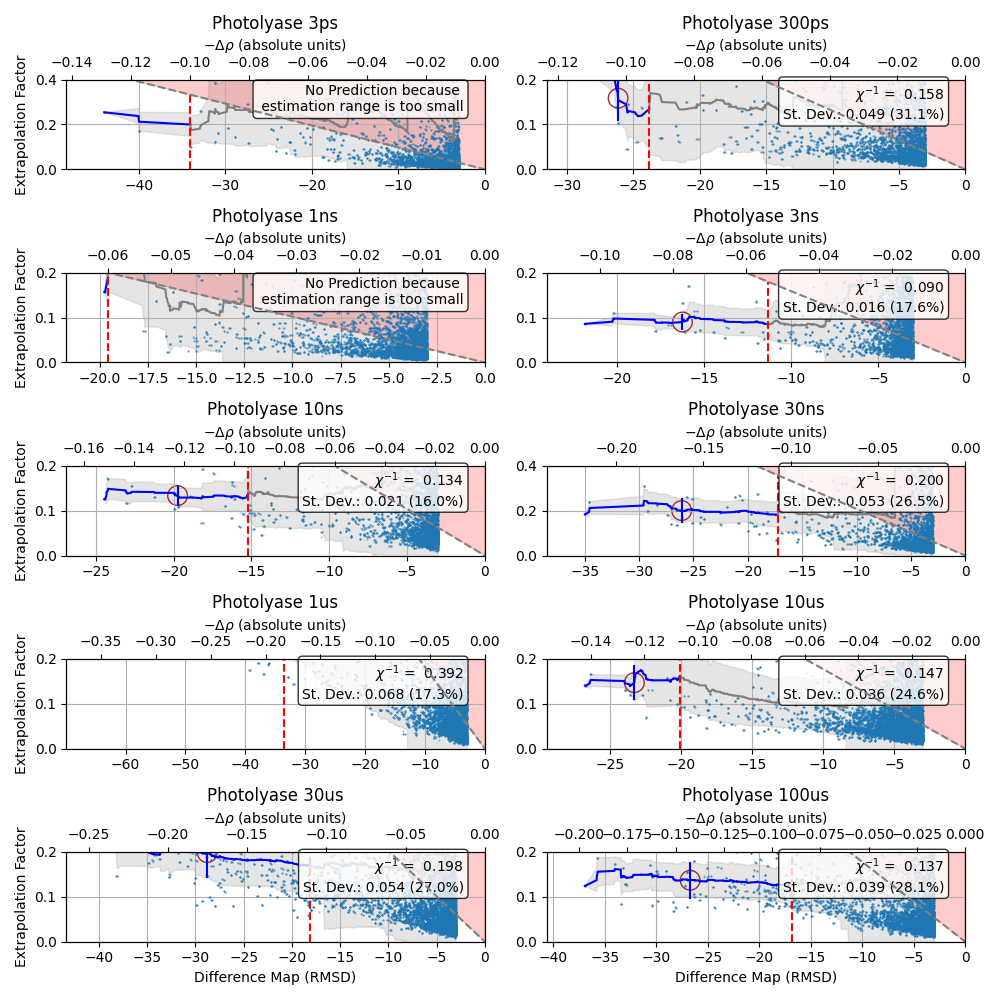

In [13]:
%matplotlib widget
from dataset_configs import get_all_PL_configs
config_list = get_all_PL_configs()
config = config_list[0]

cols = 2
rows = len(config_list)//cols+len(config_list)%cols
kwargs = dict(nrows=rows,ncols=cols, figsize=(10,10), tight_layout=True)
fig, axs = plt.subplots(**kwargs) # type: ignore
# fig, axs_old = plt.subplots(**kwargs)
for ax, config in zip(axs.flatten(),  config_list):
    config["plot"]["set_ylim"] = ((0, 0.2))
    config["masking"]["dark_size_threshold"]=0.
    # config["map_processing"]["diffmap_type"]="kweighted"
    config["map_processing"]["diffmap_v2_correction"]=True
    config["map_processing"]["diffmap_mean_correction"]=False
    config["plot"]["is_composite"] = True

    if "Photo" in config['general']['name_human']:
        print("changed plot")
        config["plot"]["set_ylim"] = ((0, 0.2))
        if any(x in config['general']['name_human'] for x in ["30ns", "3ps"]):
            config["plot"]["set_ylim"] = ((0, 0.4))

    else:
        config["plot"]["set_ylim"] = ((0, 0.4))
    try:
        loader(config, ax)
    except ValueError:
        file_name = config['general']['name_human']
        logger.error(f"Error processing config: {file_name}")
        ax.set_title(f"{file_name} - Error")
for ax in axs[-1]:
    ax.set_xlabel("Difference Map (RMSD)")
for ax in axs[:,0]:
    ax.set_ylabel("Extrapolation Factor")

# from configuration import load_figurepath
# loc = load_figurepath()
# name_fig = f"overview_real_{config['map_processing']['diffmap_type']}.pdf"
# fileloc = loc+name_fig
# fig.savefig(fileloc)
# print("Saved to", fileloc)
# plt.show()



In [ ]:
%matplotlib widget
from dataset_configs import get_all_PL_configs
config_list = get_all_PL_configs()
config = config_list [0]
cols = 2
rows = len(config_list)//cols+len(config_list)%cols
kwargs = dict(nrows=rows,ncols=cols, figsize=(10,10), tight_layout=True)
fig, axs = plt.subplots(**kwargs) # type: ignore
# fig, axs_old = plt.subplots(**kwargs)
for ax, config in zip(axs.flatten(),  config_list):
    config["general"]["high_resolution_limit"]=2.5
    config["masking"]["dark_size_threshold"]=0.
    # config["map_processing"]["diffmap_type"]="kweighted"
    config["map_processing"]["diffmap_v2_correction"]=False
    config["map_processing"]["diffmap_mean_correction"]=False
    config["plot"]["is_composite"] = True

    if config["map_processing"]["diffmap_type"]=="kweighted":
        config["plot"]["set_ylim"] = ((0, 0.2))
    elif "Photo" in config['general']['name_human']:
        print("changed plot")
        config["plot"]["set_ylim"] = ((0, 0.2))
        if any(x in config['general']['name_human'] for x in ["30ns", "3ps"]):
            config["plot"]["set_ylim"] = ((0, 0.4))

    else:
        config["plot"]["set_ylim"] = ((0, 0.4))
    try:
        loader(config, ax)
    except ValueError:
        file_name = config['general']['name_human']
        logger.error(f"Error processing config: {file_name}")
        ax.set_title(f"{file_name} - Error")
for ax in axs[-1]:
    ax.set_xlabel("Difference Map (RMSD)")
for ax in axs[:,0]:
    ax.set_ylabel("Extrapolation Factor")

# from configuration import load_figurepath
# loc = load_figurepath()
# name_fig = f"overview_real_{config['map_processing']['diffmap_type']}.pdf"
# fileloc = loc+name_fig
# fig.savefig(fileloc)
# print("Saved to", fileloc)
# plt.show()




0 11_100us/100us 11_100us
1 9_10us/10us 9_10us
3 7_30ns/30ns 7_30ns
5 3_300ps/300ps 3_300ps
6 10_30us/30us 10_30us
7 2_3ps/3ps 2_3ps
8 4_1ns/1ns 4_1ns
10 8_1us/1us 8_1us
13 6_10ns/10ns 6_10ns
14 5_3ns/3ns 5_3ns
changed plot
so
so


/Users/sbielfel/anaconda3/envs/fml/lib/python3.13/site-packages/scipy/optimize/_lsq/least_squares.py:221: RuntimeWarning: overflow encountered in square
  z = (f / f_scale) ** 2


2026-03-13 16:02:37 [info     ] scaling: native --> calculated weight_using_uncertainties=True
2026-03-13 16:02:38 [info     ] scaling: derivative --> calculated weight_using_uncertainties=True
2026-03-13 16:02:38 [info     ] Computing difference map.     
2026-03-13 16:03:05 [info     ]   using negentropy max.        kparameter=0.28
2026-03-13 16:03:05 [info     ] Searching for max-negentropy TV denoising weight method='golden-section search'
2026-03-13 16:03:05 [info     ] This may take some time...    
2026-03-13 16:03:41 [info     ] Optimal TV weight found        final_negentropy=1.90e-01 initial_negentropy=1.27e-03 weight=5.18e-03
2026-03-13 16:03:41 [info     ] scaling: native --> calculated weight_using_uncertainties=True
2026-03-13 16:03:42 [info     ] scaling: derivative --> calculated weight_using_uncertainties=True
2026-03-13 16:03:42 [info     ] Computing difference map.     
2026-03-13 16:04:10 [info     ]   using negentropy max.        kparameter=0.9
2026-03-13 16:04:10 [

2026-03-13 16:04:46,151: logger: WARNING: Diffmap Mean: -0.000000, Std: 0.002621 (vacuum_plots_many.py:36)
2026-03-13 16:04:46,199: logger: WARNING: Used threshold for posmask: 0.087, found 993 blobs (masking.py:133)
2026-03-13 16:04:46,558: logger: WARNING: Excluding an addtional 661 voxels from mask duedark map smaller than mean + 0.0 * sigma (deactivate via 'exclude_negative_dark' parameter) (masking.py:299)
2026-03-13 16:04:46,559: logger: WARNING: Excluding voxels with positive difference density from mask (activate via 'exclude_positive_diffmap' parameter) (masking.py:302)
2026-03-13 16:04:46,608: logger: WARNING: Mean of diffmap_np: -1.1071964742606633e-12, Mean of map_dark_np: 0.32782384753227234 (estimation.py:644)


changed plot
so
so


...

2026-03-13 16:07:00,773: logger: WARNING: Diffmap Mean: 0.000000, Std: 0.002911 (vacuum_plots_many.py:36)
2026-03-13 16:07:00,818: logger: WARNING: Used threshold for posmask: 0.741, found 30 blobs (masking.py:133)
2026-03-13 16:07:01,066: logger: WARNING: Excluding an addtional 151 voxels from mask duedark map smaller than mean + 0.0 * sigma (deactivate via 'exclude_negative_dark' parameter) (masking.py:299)
2026-03-13 16:07:01,066: logger: WARNING: Excluding voxels with positive difference density from mask (activate via 'exclude_positive_diffmap' parameter) (masking.py:302)
2026-03-13 16:07:01,115: logger: WARNING: Mean of diffmap_np: 4.511093365522356e-08, Mean of map_dark_np: 0.32782384753227234 (estimation.py:644)


changed plot
so
so
2026-03-13 16:07:05 [info     ] scaling: native --> calculated weight_using_uncertainties=True
2026-03-13 16:07:05 [info     ] scaling: derivative --> calculated weight_using_uncertainties=True
2026-03-13 16:07:05 [info     ] Computing difference map.     
2026-03-13 16:07:34 [info     ]   using negentropy max.        kparameter=0.86
2026-03-13 16:07:34 [info     ] Searching for max-negentropy TV denoising weight method='golden-section search'
2026-03-13 16:07:34 [info     ] This may take some time...    
2026-03-13 16:08:08 [info     ] Optimal TV weight found        final_negentropy=1.48e-01 initial_negentropy=5.98e-04 weight=4.83e-03
2026-03-13 16:08:09 [info     ] scaling: native --> calculated weight_using_uncertainties=True
2026-03-13 16:08:09 [info     ] scaling: derivative --> calculated weight_using_uncertainties=True
2026-03-13 16:08:09 [info     ] Computing difference map.     
2026-03-13 16:08:38 [info     ]   using negentropy max.        kparameter=0.92
2

2026-03-13 16:09:12,373: logger: WARNING: Diffmap Mean: -0.000000, Std: 0.003386 (vacuum_plots_many.py:36)
2026-03-13 16:09:12,417: logger: WARNING: Used threshold for posmask: 0.185, found 1503 blobs (masking.py:133)
2026-03-13 16:09:12,794: logger: WARNING: Excluding an addtional 1346 voxels from mask duedark map smaller than mean + 0.0 * sigma (deactivate via 'exclude_negative_dark' parameter) (masking.py:299)
2026-03-13 16:09:12,794: logger: WARNING: Excluding voxels with positive difference density from mask (activate via 'exclude_positive_diffmap' parameter) (masking.py:302)
2026-03-13 16:09:12,841: logger: WARNING: Mean of diffmap_np: -1.2440715124739654e-07, Mean of map_dark_np: 0.32782384753227234 (estimation.py:644)


changed plot
so
so


/Users/sbielfel/anaconda3/envs/fml/lib/python3.13/site-packages/scipy/optimize/_lsq/least_squares.py:221: RuntimeWarning: overflow encountered in square
  z = (f / f_scale) ** 2


--- Calibrating Absolute Densities for /Users/sbielfel/Nextcloud2/time_resolved/data/MAXIV_ECH_new/models/ECH_MAXIV_dark_model.pdb ---
Generating protein and solvent masks...
Estimated rho_atom offset (mean shift inside protein): 0.31616
Running 1D bounded optimization for rho_bulk...
Optimal rho_bulk: 0.2895 e-/Å³


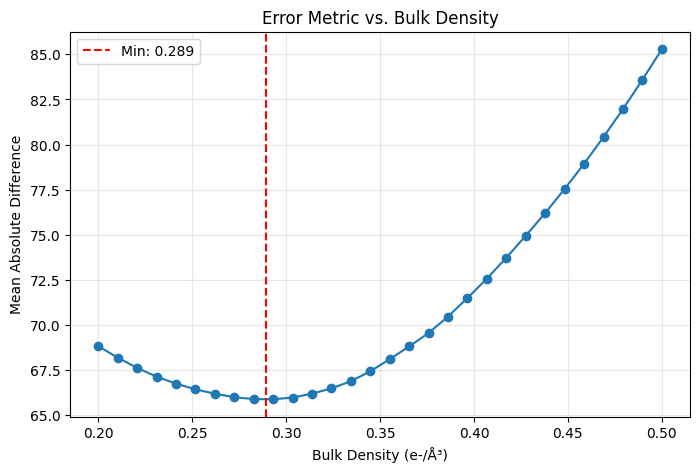

{'rho_abs_shift': np.float32(0.31615645), 'rho_atom': np.float32(0.19831474), 'rho_bulk': np.float64(0.2894980589174765), 'rho_comb': np.float64(0.3156566450344245), 'share_solvent': np.float32(0.4053288), 'f000': np.float64(169300.65767657725)}
--- Calibrating Absolute Densities for /Users/sbielfel/Nextcloud2/time_resolved/data/ECH2/ECH_MAXIV_dark_new_prefin.pdb ---
Generating protein and solvent masks...
Estimated rho_atom offset (mean shift inside protein): 0.31821
Running 1D bounded optimization for rho_bulk...


2026-03-11 18:07:08,243: logger: ERROR: Error occurred while autoshifting: Unalignable boolean Series provided as indexer (index of the boolean Series and of the indexed object do not match). (869035562.py:29)
/Users/sbielfel/anaconda3/envs/fml/lib/python3.13/site-packages/scipy/optimize/_lsq/least_squares.py:221: RuntimeWarning: overflow encountered in square
  z = (f / f_scale) ** 2


--- Calibrating Absolute Densities for /Users/sbielfel/Nextcloud2/time_resolved/meteor/test/data/8a6g.pdb ---
Generating protein and solvent masks...
Estimated rho_atom offset (mean shift inside protein): 0.32021
Running 1D bounded optimization for rho_bulk...
Optimal rho_bulk: 0.2985 e-/Å³


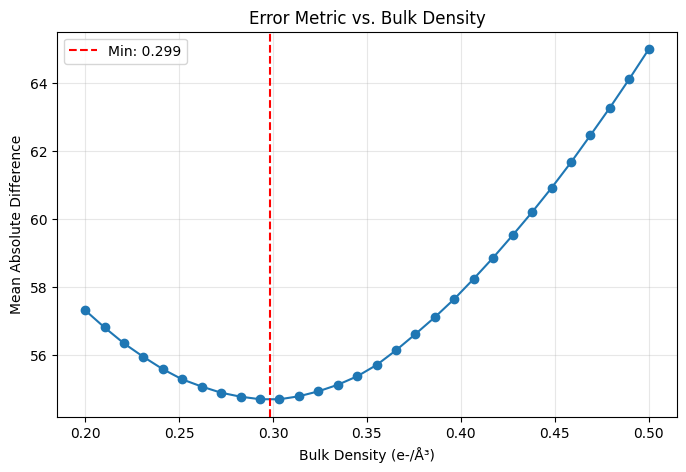

{'rho_abs_shift': np.float32(0.32020813), 'rho_atom': np.float32(0.22628872), 'rho_bulk': np.float64(0.29853981315943934), 'rho_comb': np.float64(0.3245380349363915), 'share_solvent': np.float32(0.32909954), 'f000': np.float64(76457.22293299143)}
--- Calibrating Absolute Densities for /Users/sbielfel/Nextcloud2/time_resolved/data/MAXIV_CAN_new/CAN_MAXIV_dark_prefin.pdb ---
Generating protein and solvent masks...
Estimated rho_atom offset (mean shift inside protein): 0.31772
Running 1D bounded optimization for rho_bulk...


KeyboardInterrupt: 

In [ ]:
plt.close("all")
%matplotlib inline
import gemmi
from meteor.sfcalc import gemmi_structure_to_calculated_map
from meteor.scale import scale_maps
import numpy as np
import reciprocalspaceship as rs
from meteor import rsmap
from processing import autoshift_rsmap, cut_resolution
config_list = get_all_configs()
cols = 3
rows = len(config_list)//cols+len(config_list)%cols
kwargs = dict(nrows=rows,ncols=cols, figsize=(10,10), tight_layout=True)
for  i, config in enumerate(config_list):
    # if i<2:
    #     continue
    struc = gemmi.read_pdb(config["input_files"]["pdb_dark"])
    map_dark_comp = gemmi_structure_to_calculated_map(
        struc, high_resolution_limit=config["general"]["high_resolution_limit"],
    )
    ds_dark = rs.read_mtz(config["input_files"]["map_dark"])
    rmap = rsmap.Map(ds_dark, **config["input_files"]["columns_dark"])
    rmap.canonicalize_amplitudes()
    rmap = scale_maps(reference_map=map_dark_comp, map_to_scale=rmap)
    rmap = cut_resolution(rmap, high_resolution_limit=config["general"]["high_resolution_limit"])
    try:
        rmap, _ = autoshift_rsmap(rmap, config["general"], map_dark_comp, diagnostic_plots=True)
    except Exception as e:
        logger.error(f"Error occurred while autoshifting: {e}")


In [ ]:
# import gemmi
# from meteor.sfcalc import gemmi_structure_to_calculated_map
# from meteor.scale import scale_maps
# import numpy as np
# import reciprocalspaceship as rs
# from meteor import rsmap
# from processing import autoshift_rsmap, cut_resolution

# def make_map(dataloc, map_dark_comp, columns):
#     ds = rs.read_mtz(dataloc)
#     # ds["F"] = np.sqrt(np.abs(ds["I"]))*np.sign(ds["I"])
#     # ds["SIGF"] = np.sqrt(ds["SIGI"]/(2*np.abs(ds["I"])+1))
#     # ds["PHIC"] = map_dark_comp.phases
#     rmap = rsmap.Map(ds, **columns)
#     rmap.canonicalize_amplitudes()
#     rmap = scale_maps(reference_map=map_dark_comp, map_to_scale=rmap)
#     rmap = autoshift_rsmap(rmap, general_config, map_dark_comp)
#     return rmap

# def calc_maps( 
#     dataloc_dark,
#     dataloc_light, 
#     pdbloc_dark,
#     dmin=1.8,
# ):
#     dark_columns = dict(
#         amplitude_column="F",
#         phase_column="PHIC",
#         uncertainty_column="SIGF",
#     )
#     light_columns = dict(
#         amplitude_column="F",
#         phase_column="PHIC",
#         uncertainty_column="SIGF",
#     )
#     struc = gemmi.read_pdb(pdbloc_dark)
#     map_dark_comp = gemmi_structure_to_calculated_map(
#         struc, high_resolution_limit=dmin,
#     )
#     ds = rs.read_mtz(dataloc)
#     # ds["F"] = np.sqrt(np.abs(ds["I"]))*np.sign(ds["I"])
#     # ds["SIGF"] = np.sqrt(ds["SIGI"]/(2*np.abs(ds["I"])+1))
#     # ds["PHIC"] = map_dark_comp.phases
#     rmap = rsmap.Map(ds, **columns)
#     rmap.canonicalize_amplitudes()
#     rmap = scale_maps(reference_map=map_dark_comp, map_to_scale=rmap)
#     rmap = autoshift_rsmap(rmap, general_config, map_dark_comp)
#     # map_dark = make_map(dataloc_dark, map_dark_comp, dark_columns)
#     # map_light = make_map(dataloc_light, map_dark_comp, light_columns)
#     # map_light.cell = map_dark.cell
#     # map_dark = cut_resolution(map_dark, high_resolution_limit=dmin)
#     # map_light = cut_resolution(map_light, high_resolution_limit=dmin)
#     return  map_dark 

# from configuration import load_homepath
# homepath = load_homepath()
# folderloc = homepath + "data/esther/"
